# CC3092 – Laboratorio 7: ETTh1 Forecasting

**Dataset:** ETTh1 (Electricity Transformer Temperature – hourly, 2 years)  
**Variable objetivo:** `OT` (Oil Temperature)  
**Horizontes de predicción:** h = 24 h y h = 48 h  

> **NOTA:** Todo el código de las secciones marcadas debe implementarse con tensores PyTorch puros.  
> No se permite usar `nn.LSTM`, `nn.MultiheadAttention` ni ninguna capa de alto nivel que implemente  
> la arquitectura por usted. Puede usar `nn.Linear`, `nn.Parameter`, `torch.optim.Adam` y `loss.backward()` normalmente.

---
## Task 1 – Preprocesamiento y Análisis Exploratorio

### Task 1.1 – Descarga, normalización, split y ventanas deslizantes

In [19]:
# ── Imports globales ──────────────────────────────────────────────────────────
import urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

In [20]:
# ── Descarga de ETTh1 ─────────────────────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/zhouhaoyi/"
    "ETDataset/main/ETT-small/ETTh1.csv"
)
urllib.request.urlretrieve(URL, "ETTh1.csv")
print("ETTh1.csv descargado.")

ETTh1.csv descargado.


In [21]:
# ── Carga con np.genfromtxt ───────────────────────────────────────────────────
# Columnas: date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT
# skip_header=1 descarta la fila de encabezados
data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)

OT  = data[:, -1].astype(np.float32)   # columna objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)   # 7 variables: 6 de carga + OT

print(f"Total de muestras: {len(OT)}")
print(f"ALL shape:         {ALL.shape}")
print(f"OT min/max:        {OT.min():.2f} / {OT.max():.2f}")

Total de muestras: 17420
ALL shape:         (17420, 7)
OT min/max:        -4.08 / 46.01


In [22]:
# ── 1.1 a) Normalización z-score de OT ───────────────────────────────────────
# OT_norm = (OT - mu) / sigma
# Guardamos mu y sigma para poder desnormalizar predicciones en Tasks 2/3/4.
mu    = float(OT.mean())         # media muestral
sigma = float(OT.std())          # desviación estándar muestral

OT_norm = (OT - mu) / sigma      # array numpy normalizado

print(f"mu    = {mu:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"OT_norm media ≈ {OT_norm.mean():.6f}  (debe ser ~0)")
print(f"OT_norm std  ≈ {OT_norm.std():.6f}  (debe ser ~1)")

mu    = 13.3247
sigma = 8.5667
OT_norm media ≈ -0.000000  (debe ser ~0)
OT_norm std  ≈ 1.000000  (debe ser ~1)


In [23]:
# ── 1.1 b) Split temporal contiguo (sin mezcla aleatoria) ────────────────────
# 60 % entrenamiento | 20 % validación | 20 % prueba
# El split es por bloques contiguos para respetar el orden temporal.
N       = len(OT_norm)
n_train = int(0.60 * N)
n_val   = int(0.20 * N)
n_test  = N - n_train - n_val   # resto exacto (no se pierde ningún dato)

# Convertimos a tensores PyTorch float32 para usarlos directamente con torch.abs, etc.
OT_train = torch.tensor(OT_norm[:n_train],              dtype=torch.float32)
OT_val   = torch.tensor(OT_norm[n_train:n_train+n_val], dtype=torch.float32)
OT_test  = torch.tensor(OT_norm[n_train+n_val:],        dtype=torch.float32)

print(f"Total:      {N}")
print(f"OT_train:   {len(OT_train):,}  ({len(OT_train)/N*100:.1f} %)")
print(f"OT_val:     {len(OT_val):,}  ({len(OT_val)/N*100:.1f} %)")
print(f"OT_test:    {len(OT_test):,}  ({len(OT_test)/N*100:.1f} %)")

# Verificación básica: los splits son contiguos, sin solape
assert len(OT_train) + len(OT_val) + len(OT_test) == N
assert OT_train[-1] != OT_val[0], "El último punto de train no debe ser el primero de val"
print("Split OK – ningún dato perdido, sin solape.")

Total:      17420
OT_train:   10,452  (60.0 %)
OT_val:     3,484  (20.0 %)
OT_test:    3,484  (20.0 %)
Split OK – ningún dato perdido, sin solape.


In [24]:
# ── 1.1 c) make_windows(series, L, H) ────────────────────────────────────────
# Construye ventanas deslizantes sobre una serie 1D (tensor PyTorch).
#
# Para cada posición t en [L-1, N-H-1]:
#   X(t) = (x_{t-L+1}, ..., x_t)   → ventana de contexto de longitud L
#   y(t) = x_{t+H}                 → valor objetivo a H pasos en el futuro
#
# Retorna:
#   X : tensor de forma (N_ventanas, L)
#   y : tensor de forma (N_ventanas,)

def make_windows(series: torch.Tensor, L: int, H: int):
    """
    Genera ventanas deslizantes.

    Args:
        series : tensor 1D de longitud T
        L      : longitud de la ventana de entrada (lookback)
        H      : horizonte de predicción

    Returns:
        X : (N, L) – ventanas de entrada
        y : (N,)   – valores objetivo
    """
    # Número de ventanas posibles
    # El primer índice objetivo es t=L-1+H, el último es T-1
    T = len(series)
    N_windows = T - L - H + 1   # equivalente a len(range(L-1, T-H))

    # Construcción vectorizada usando strides para eficiencia
    # xs[i] = series[i : i+L]  → ventana de entrada
    # ys[i] = series[i+L-1+H]  → objetivo
    xs = torch.stack([series[i:i+L]    for i in range(N_windows)])
    ys = torch.stack([series[i+L-1+H]  for i in range(N_windows)])
    return xs, ys


# Parámetros
L = 96   # longitud de ventana: 96 h = 4 días

# Horizonte h = 24 h
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

# Horizonte h = 48 h
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

print("Ventanas generadas:")
print(f"  h=24 → X_tr_24: {X_tr_24.shape}, y_tr_24: {y_tr_24.shape}")
print(f"  h=24 → X_vl_24: {X_vl_24.shape}, y_vl_24: {y_vl_24.shape}")
print(f"  h=24 → X_te_24: {X_te_24.shape}, y_te_24: {y_te_24.shape}")
print(f"  h=48 → X_tr_48: {X_tr_48.shape}, y_tr_48: {y_tr_48.shape}")
print(f"  h=48 → X_vl_48: {X_vl_48.shape}, y_vl_48: {y_vl_48.shape}")
print(f"  h=48 → X_te_48: {X_te_48.shape}, y_te_48: {y_te_48.shape}")

Ventanas generadas:
  h=24 → X_tr_24: torch.Size([10333, 96]), y_tr_24: torch.Size([10333])
  h=24 → X_vl_24: torch.Size([3365, 96]), y_vl_24: torch.Size([3365])
  h=24 → X_te_24: torch.Size([3365, 96]), y_te_24: torch.Size([3365])
  h=48 → X_tr_48: torch.Size([10309, 96]), y_tr_48: torch.Size([10309])
  h=48 → X_vl_48: torch.Size([3341, 96]), y_vl_48: torch.Size([3341])
  h=48 → X_te_48: torch.Size([3341, 96]), y_te_48: torch.Size([3341])


### Task 1.2 – Función de Autocorrelación (ACF) y correlograma

In [25]:
# ── 1.2 a) Implementación manual de la ACF ────────────────────────────────────
# La autocorrelación mide la correlación de una serie consigo misma desplazada k pasos.
#
# Fórmula:
#             (1/(N-k)) * Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄)
#  ρ(k) = ──────────────────────────────────────────────────────────
#                    (1/N) * Σ_{t=0}^{N-1} (x_t - x̄)²
#
# El denominador es la varianza muestral (corrección N, no N-1).

def acf_manual(series: np.ndarray, max_lag: int) -> np.ndarray:
    """
    Calcula la función de autocorrelación (ACF) para lags 0, 1, ..., max_lag.

    Args:
        series  : array numpy 1D
        max_lag : número máximo de lags a calcular

    Returns:
        rhos : array de longitud (max_lag + 1) con ρ(0), ρ(1), ..., ρ(max_lag)
    """
    x  = np.asarray(series, dtype=np.float64)
    xb = x.mean()                         # media muestral x̄
    N  = len(x)
    xc = x - xb                           # serie centrada

    # Denominador: varianza con factor 1/N (denominador fijo para todos los lags)
    var = np.dot(xc, xc) / N             # (1/N) * Σ(x_t - x̄)²

    rhos = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # Numerador: covarianza con lag k, factor 1/(N-k)
        # Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄)
        cov_k = np.dot(xc[k:], xc[:N-k]) / (N - k)
        rhos[k] = cov_k / var            # ρ(k) = cov(k) / var

    return rhos


# ── Cálculo sobre OT_train con max_lag=96 ────────────────────────────────────
MAX_LAG = 96
acf_vals = acf_manual(OT_train.numpy(), MAX_LAG)

print(f"ACF lag  0 (auto-correlación): {acf_vals[0]:.4f}  (siempre = 1)")
print(f"ACF lag 24 (1 día):            {acf_vals[24]:.4f}")
print(f"ACF lag 48 (2 días):           {acf_vals[48]:.4f}")
print(f"ACF lag 96 (4 días / L):       {acf_vals[96]:.4f}")

ACF lag  0 (auto-correlación): 1.0000  (siempre = 1)
ACF lag 24 (1 día):            0.9250
ACF lag 48 (2 días):           0.8763
ACF lag 96 (4 días / L):       0.8489


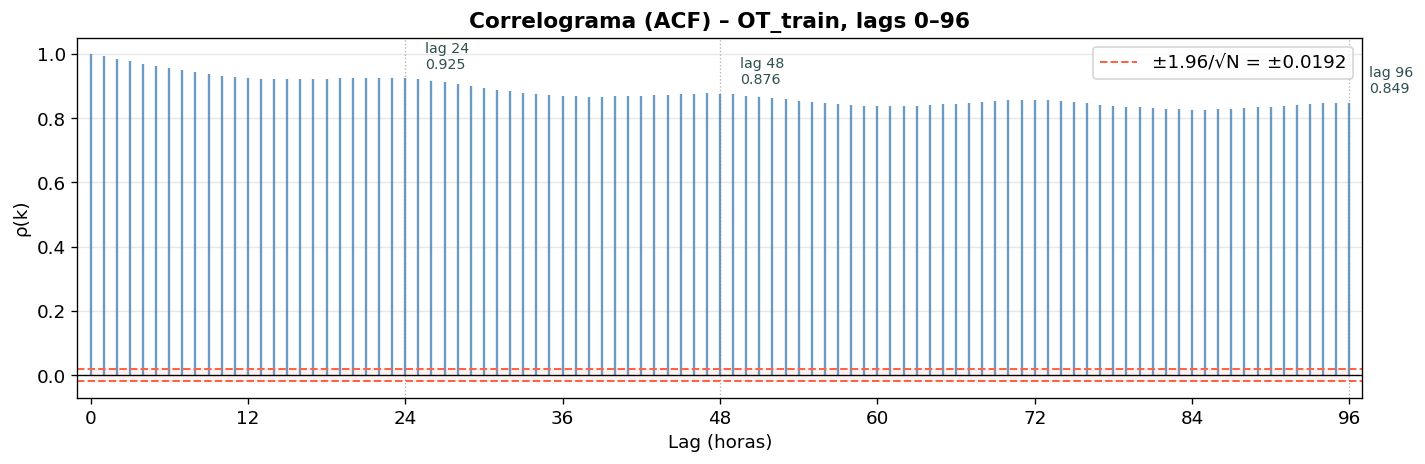

Figura guardada en acf_OT_train.png

Pico más alto  (excl. lag 0): lag  22  ρ = 0.9262
Segundo pico más alto:        lag  47  ρ = 0.8770


In [26]:
# ── Correlograma con líneas de confianza al 95 % (±1.96/√N) ──────────────────
N_train = len(OT_train)
conf    = 1.96 / np.sqrt(N_train)   # límite de confianza bilateral al 95 %

lags = np.arange(MAX_LAG + 1)

fig, ax = plt.subplots(figsize=(12, 4))

# Barras verticales (stem plot estilo correlograma)
ax.vlines(lags, 0, acf_vals, colors='steelblue', linewidth=1.4, alpha=0.8)
ax.axhline(0,    color='black', linewidth=0.8)

# Líneas de confianza al 95 %
ax.axhline( conf, color='tomato', linewidth=1.2, linestyle='--', label=f'±1.96/√N = ±{conf:.4f}')
ax.axhline(-conf, color='tomato', linewidth=1.2, linestyle='--')
ax.fill_between(lags, -conf, conf, color='tomato', alpha=0.08)

# Marcadores en lags clave
for lag_key in [24, 48, 96]:
    ax.axvline(lag_key, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.annotate(
        f'lag {lag_key}\n{acf_vals[lag_key]:.3f}',
        xy=(lag_key, acf_vals[lag_key]),
        xytext=(lag_key + 1.5, acf_vals[lag_key] + 0.03),
        fontsize=8.5,
        color='darkslategray'
    )

ax.set_title('Correlograma (ACF) – OT_train, lags 0–96', fontweight='bold')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('ρ(k)')
ax.set_xlim(-1, MAX_LAG + 1)
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('acf_OT_train.png', bbox_inches='tight')
plt.show()
print(f"Figura guardada en acf_OT_train.png")

# Identificar segundo pico más alto (después de lag 0)
# El primer pico es siempre lag 0 (= 1.0); buscamos el siguiente máximo local.
from scipy.signal import find_peaks
peaks_idx, _ = find_peaks(acf_vals)
if len(peaks_idx) > 0:
    sorted_peaks = sorted(peaks_idx, key=lambda p: acf_vals[p], reverse=True)
    top_lag      = sorted_peaks[0]
    top_val      = acf_vals[top_lag]
    print(f"\nPico más alto  (excl. lag 0): lag {top_lag:3d}  ρ = {top_val:.4f}")
    if len(sorted_peaks) > 1:
        sec_lag = sorted_peaks[1]
        sec_val = acf_vals[sec_lag]
        print(f"Segundo pico más alto:        lag {sec_lag:3d}  ρ = {sec_val:.4f}")

In [27]:
# ── Verificación Task 1 (celdas exactas del enunciado) ────────────────────────
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El último valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto número de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


---
## Task 2 – LSTM Many-to-One (PyTorch puro)

> *Celda pendiente – agregar código de Task 2 aquí.*

---
## Task 3 – Transformer Encoder con Self-Attention Temporal (PyTorch puro)

> *Celda pendiente – agregar código de Task 3 aquí.*

---
## Task 4 – Comparación y Análisis Final

> *Celda pendiente – agregar código de Task 4 aquí.*